In [ ]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt

In [1]:
script_dir = os.getcwd()
# script_dir = os.path.dirname(os.path.abspath(__file__))
image_path = os.path.join(script_dir,'data/line_avi_dataset/data/images/train/extracted_20f','01_0012.jpg')

print(script_dir)
print(image_path)

NameError: name 'os' is not defined

#보조함수 세팅

In [ ]:
def showimg(img1,img2, title1 = 'Original', title2 = 'Processed') : #plt로 이미지 출력을 도와주는
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB) #cv는 RGR 채널을 사용하기에 plt로 보여주기 위해 RGB로 변화시킨다.
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB) 

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.title(title1)
    plt.imshow(img1_rgb)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(title2)
    plt.imshow(img2_rgb)
    plt.axis('off')

    plt.show()

    return

def draw_roi(img, points, color=(0,255,0), thickness=2):
    img_copy = img.copy()

    if len(img_copy.shape) == 2:  
        color_img = cv2.cvtColor(img_copy, cv2.COLOR_GRAY2BGR)
    else :
        color_img = img_copy

    pts = np.array(points, dtype=np.int32).reshape((-1,1,2))
    cv2.polylines(color_img, [pts], isClosed=True, color=color, thickness=thickness)
    plt.title("ROI")
    plt.imshow(color_img) 
    return 


class ROISelector:
    def __init__(self, window_name, image):
        self.window_name = window_name
        self.image = image.copy()
        self.clone = image.copy()
        self.points = []
        self.done = False
        
        cv2.namedWindow(self.window_name)
        cv2.setMouseCallback(self.window_name, self.mouse_event)
    
    def mouse_event(self, event, x, y, flags, param):
        # 마우스 좌클릭 시 좌표 저장 및 표시
        if event == cv2.EVENT_LBUTTONDOWN:
            if len(self.points) < 4:
                self.points.append((x, y))
                cv2.circle(self.image, (x, y), 5, (0, 255, 0), -1)
                cv2.putText(self.image, f"{len(self.points)}", (x+10, y-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
                cv2.imshow(self.window_name, self.image)
            if len(self.points) == 4:
                self.done = True
    
    def get_points(self):
        # ROI 선택 완료 시 좌표 반환
        while not self.done:
            cv2.imshow(self.window_name, self.image)
            key = cv2.waitKey(1) & 0xFF
            # ESC 키 눌러서 종료 가능
            if key == 27:
                break
        
        cv2.destroyWindow(self.window_name)
        return self.points

# 사용 예시

#selector = ROISelector("Select ROI - Click 4 points", img)
#roi_points = selector.get_points() #좌하단 좌상단 우상단 우하단을 순서대로 클릭
    
#if len(roi_points) == 4:
#    print("Selected points:", roi_points)
#else:
#    print("ROI selection cancelled or incomplete")

##전처리

In [ ]:
img = cv2.imread(image_path)

print(type(img))
print(img.shape)

<class 'numpy.ndarray'>
(480, 640, 3)


보간법을 사용한 resize

In [ ]:
img_conv = cv2.resize(img, (640, 480),interpolation=cv2.INTER_LINEAR)  # 크기 조정

색공간 필터링
1. cv2.cvtColor : 색영역 변경
2. cv2.inRange : 최소,최대 값 사이에 속하는 픽셀을 찾아서 범위에 속하면 흰색 (255) , 벗어난 것은 검정색 (0)으로 마스크 생성
3. bitwise_or : or 연산으로 두개 마스크를 합침 


(480, 640)


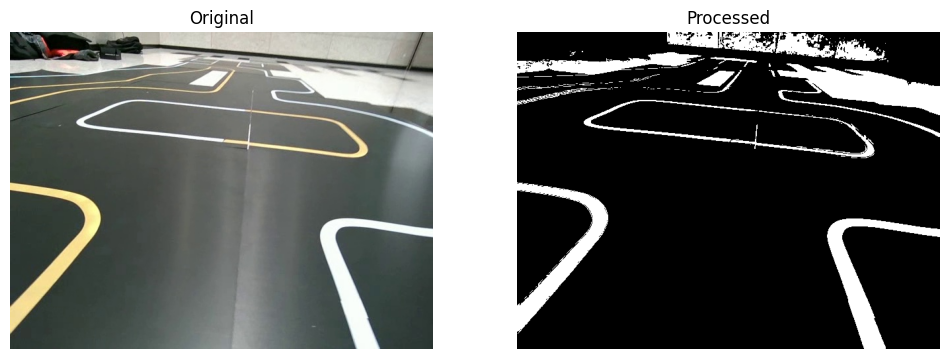

In [ ]:
#색공간 변경 HLS로 white 검출, HSV로 노란색 차선 검출
hls = cv2.cvtColor(img_conv, cv2.COLOR_BGR2HLS)
hsv = cv2.cvtColor(img_conv, cv2.COLOR_BGR2HSV)


# 흰색 차선 (HLS) - 높은 L = 흰색
lower_white = np.array([0, 200, 0])
upper_white = np.array([180, 255, 255])
mask_white = cv2.inRange(hls, lower_white, upper_white)

# 노란색 차선 (HSV) - 10~40의 H 노란색
lower_yellow = np.array([15, 80, 80])
upper_yellow = np.array([35, 255, 255])
mask_yellow = cv2.inRange(hsv, lower_yellow, upper_yellow)

mask_line = cv2.bitwise_or(mask_white,mask_yellow)

print(mask_line.shape)
showimg(img,mask_line)

### 노이즈 제거 
1. GaussianBlur : 가우시안 블러 커널 사이즈 5 * 5로 기본 진행
2. 모폴로지 연산 : 팽창 -> 침식의 순서로 노이즈제거 -> 내부 작은 픽셀 지우기를 실행

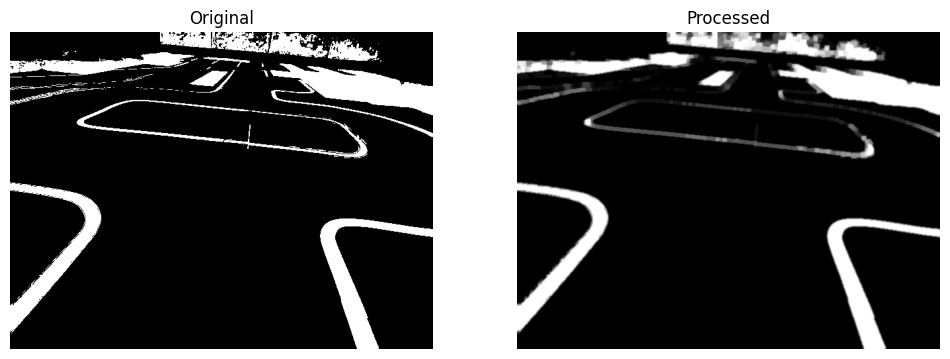

(480, 640)


In [ ]:
img_conv = cv2.GaussianBlur(mask_line, (5, 5), 0)  # 노이즈 제거

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

img_conv = cv2.morphologyEx(img_conv, cv2.MORPH_OPEN, kernel)
img_conv = cv2.morphologyEx(img_conv, cv2.MORPH_CLOSE, kernel)

showimg(mask_line,img_conv)
print(img_conv.shape)

### bird's eyes view 전환

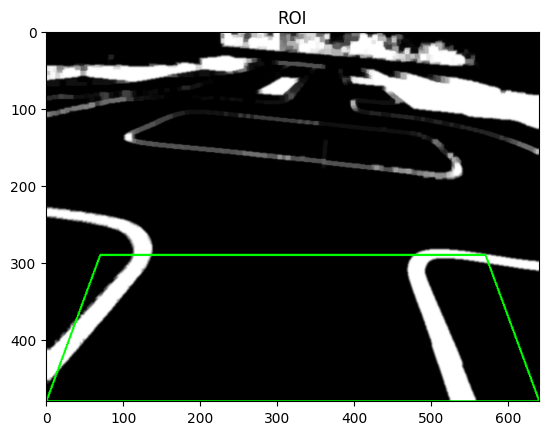

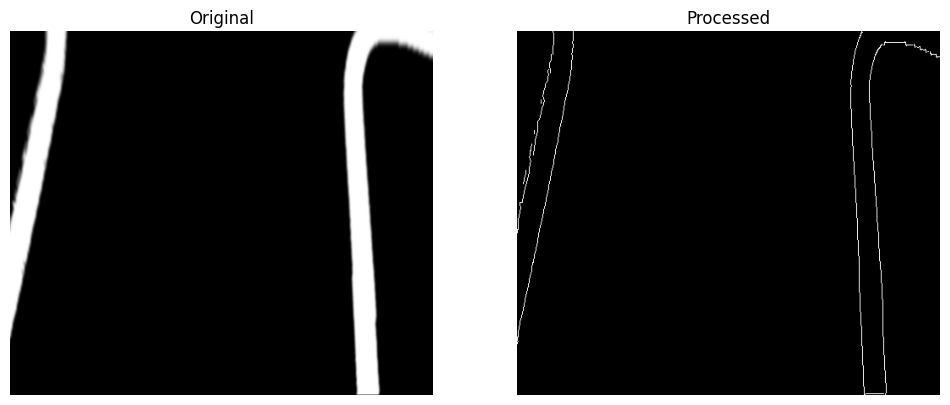

In [ ]:

# bird's eye view를 적용할 roi를 넘파이 배열로 지정
src = np.array([[70, 290],[570, 290],[640, 480],[0, 480]], dtype=np.float32) #좌상단 우상단 우하단 좌하단
draw_roi(img_conv,src) # 지정한 ROI 영역을 시각화

# 변환할 직사각형 영역 정의
width, height = 500, 430
dst = np.float32([[0, 0], [width, 0], [width, height], [0, height]]) #좌상단 우상단 우하단 좌하단

# 투시 변환 행렬 계산
M = cv2.getPerspectiveTransform(src, dst)

# 원근 변환 적용
bird_eye_view = cv2.warpPerspective(img_conv, M, (width, height))
img_conv = bird_eye_view

img_conv = cv2.Canny(image=bird_eye_view, threshold1=50, threshold2=150)

# 결과 출력
showimg(bird_eye_view,img_conv)

### 슬라이딩 윈도우 
1. 히스토그램을 통한 시작점 찾기 
2. 슬라이딩 윈도우를 통한 윈도우 쌓기
3. 윈도우 안에 있는 차선들 마스킹
4. 해당 차선들 이차함수로 근사
5. 예외처리 : 한쪽 차선만 인식되는 경우 이전 프레임의 차선 정보를 활용

right_detected
422
right_detected
421
right_detected
420
right_detected
419
right_detected
418
right_detected
418
right_detected
417
right_detected
416
right_detected
414
left_detected
14
right_detected
413
left_detected
16
right_detected
412
left_detected
21
right_detected
411
left_detected
22
right_detected
410
left_detected
27
right_detected
408
left_detected
32
right_detected
407
left_detected
39
right_detected
406
left_detected
41
right_detected
405
left_detected
47
right_detected
405
left_detected
49
right_detected
407
left_detected
53
right_detected
431
[(None, 419), (None, 398), (None, 377), (None, 356), (None, 335), (None, 314), (None, 293), (None, 272), (None, 251), (14, 230), (16, 209), (21, 188), (22, 167), (27, 146), (32, 125), (39, 104), (41, 83), (47, 62), (49, 41), (53, 20)]
[(422, 419), (421, 398), (420, 377), (419, 356), (418, 335), (418, 314), (417, 293), (416, 272), (414, 251), (413, 230), (412, 209), (411, 188), (410, 167), (408, 146), (407, 125), (406, 104), (405,

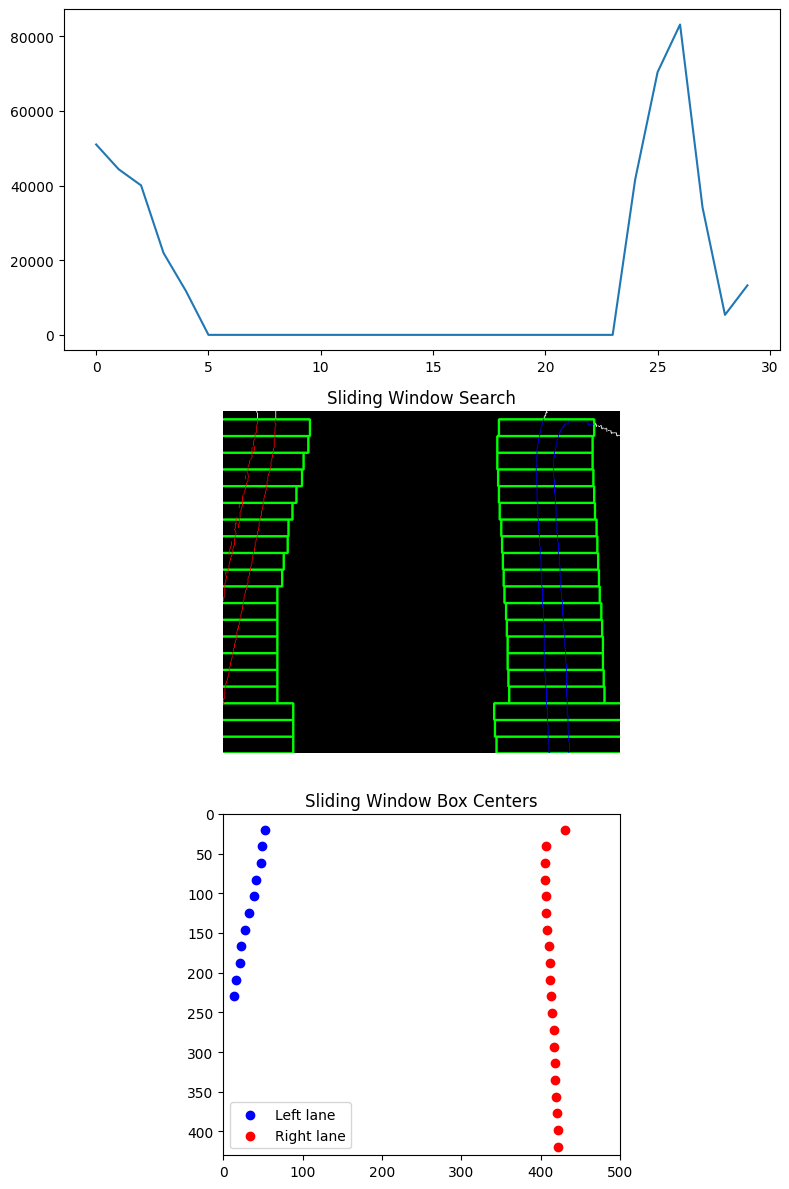

In [ ]:
# 버드아이뷰 이진 이미지 (0,255)
binary_warped = img_conv  # 예: cv2.imread('bird_eye_binary.jpg', 0)

"""
1. sliding window base 위치 찾기 
    - 받아온 이미지를 가로로 나누어 만든 N개의직사각형 중, 비트합을 하였을 때, midpoint를 기준으로 좌측과 우측의 최댓값을 base로 선정
"""
H,W = binary_warped.shape

basefindgrid_N = 30 # 튜닝필요 파라미터
basefindgrid_margin = W // basefindgrid_N
basefindgrid_midpoint = basefindgrid_N // 2

findbase_score = []
findbase_edge = []

for i in range(basefindgrid_N) :
    x1 = i * basefindgrid_margin
    x2 = W if i == basefindgrid_N -1 else (i+1)*basefindgrid_margin # 마지막 grid일 경우 대비 보정항
    
    temp = np.sum(binary_warped[:, x1:x2])
    findbase_score.append(temp)
    findbase_edge.append((x1,x2))

findbase_score = np.array(findbase_score)

left_max_idx = np.argmax(findbase_score[:basefindgrid_midpoint])
right_max_idx = np.argmax(findbase_score[basefindgrid_midpoint:])  
right_max_idx = basefindgrid_midpoint + right_max_idx

left_max_idx = int(left_max_idx)
right_max_idx = int(right_max_idx)

x1,x2 = findbase_edge[left_max_idx]
leftx_base = (x1+x2)//2

x1,x2 = findbase_edge[right_max_idx]
rightx_base = (x1+x2)//2


"""
2. sliding window를 통한 차선 중심 탐색
    
"""

# 슬라이딩 윈도우 설정
nwindows = 20
window_height = binary_warped.shape[0] // nwindows
h_margin = 60
l_margin = 80

minpix = 40
maxpix = 200

leftx_current = leftx_base
rightx_current = rightx_base

nonzero = binary_warped.nonzero()
nonzeroy = np.array(nonzero[0])
nonzerox = np.array(nonzero[1])

left_lane_inds = []
right_lane_inds = []
left_box_centor = []
right_box_centor = []

# 원본 이진 이미지 컬러로 변환 (윈도우 박스 그리기용)
out_img = np.dstack((binary_warped, binary_warped, binary_warped))

left_flag = 0
right_flag = 0

"""
1. 처음 n개의 윈도우 크기와 위의 window 크기를 다르게 적용
2. 각 window에서 감지된 차선 픽셀들의 무게중심 계산
    감지된 픽셀이 임계치 이하인 경우 차선이 없음으로 인식 -> None 처리
3. 각 무게중심을 이어서 2차함수로 피팅
"""

for window in range(nwindows):
    
    if (window <= 2 and window >= 0): 
        margin = l_margin
    else : 
        margin = h_margin
        
    win_y_low = binary_warped.shape[0] - (window+1)*window_height
    win_y_high = binary_warped.shape[0] - window*window_height

    win_xleft_low = leftx_current - margin
    win_xleft_high = leftx_current + margin
    win_xright_low = rightx_current - margin
    win_xright_high = rightx_current + margin

    # 윈도우 사각형 그리기
    if left_flag == 0  : 
        cv2.rectangle(out_img, (win_xleft_low, win_y_low), (win_xleft_high, win_y_high), (0,255,0), 2)
    if right_flag == 0  : 
        cv2.rectangle(out_img, (win_xright_low, win_y_low), (win_xright_high, win_y_high), (0,255,0), 2)

    # 윈도우 내 픽셀 인덱스 추출
    good_left_inds = ((nonzeroy >= win_y_low) & (nonzeroy < win_y_high) &
                      (nonzerox >= win_xleft_low) & (nonzerox < win_xleft_high)).nonzero()[0]
    good_right_inds = ((nonzeroy >= win_y_low) & (nonzeroy < win_y_high) &
                       (nonzerox >= win_xright_low) & (nonzerox < win_xright_high)).nonzero()[0]

    left_lane_inds.append(good_left_inds)
    right_lane_inds.append(good_right_inds)

    # 윈도우의 무게중심 위치를 centor 변수에 저장, 리스트에 넣음

    if len(good_left_inds) > minpix :
        left_x_centor = int(np.mean(nonzerox[good_left_inds]))
        print("left_detected")
        print(left_x_centor)
    else :
        #print(len(good_left_inds))
        left_x_centor = None
        
    if len(good_right_inds) > minpix : 
        right_x_centor = int(np.mean(nonzerox[good_right_inds]))
        print("right_detected")
        print(right_x_centor)
    else : 
        right_x_centor = None

    y_centor = (win_y_low+win_y_high)//2
    left_box_centor.append((left_x_centor,y_centor))
    right_box_centor.append((right_x_centor,y_centor))
    
    if len(good_left_inds) > minpix:
        leftx_current = int(np.mean(nonzerox[good_left_inds]))
    if len(good_right_inds) > minpix:
        rightx_current = int(np.mean(nonzerox[good_right_inds]))

##sliding window 결과 point 배열, 튜블이 들어있는 배열 윈도우 안 픽셀의 무게중심/일정치 이하면 None , 윈도우의 높이
print(left_box_centor)
print(right_box_centor)

    
# 이미지 크기
h, w = binary_warped.shape

# 차선 중심 좌표에서 None 제거
left_box_clean = [p for p in left_box_centor if p[0] is not None]
right_box_clean = [p for p in right_box_centor if p[0] is not None]

# Figure 및 subplot 설정
fig, (ax2, ax3, ax1) = plt.subplots(3, 1, figsize=(8, 12))

ax2.plot(findbase_score)

# 슬라이딩 윈도우 산점도
ax1.scatter([p[0] for p in left_box_clean], [p[1] for p in left_box_clean], label="Left lane", color='blue')
ax1.scatter([p[0] for p in right_box_clean], [p[1] for p in right_box_clean], label="Right lane", color='red')
ax1.set_xlim(0, w)
ax1.set_ylim(0, h)
ax1.set_aspect('equal', adjustable='box')
ax1.set_title('Sliding Window Box Centers')
ax1.legend()
ax1.invert_yaxis()  # OpenCV 좌표와 일치시키려면 y축 뒤집기


# 3차선 픽셀 색칠 이미지
# 차선 픽셀 좌표 결합
left_lane_inds = np.concatenate(left_lane_inds)
right_lane_inds = np.concatenate(right_lane_inds)

out_img[nonzeroy[left_lane_inds], nonzerox[left_lane_inds]] = [255, 0, 0]
out_img[nonzeroy[right_lane_inds], nonzerox[right_lane_inds]] = [0, 0, 255]

ax3.imshow(out_img)
ax3.set_title('Sliding Window Search')
ax3.axis('off')
ax3.set_aspect('equal')

plt.tight_layout()
plt.show()


In [ ]:
print(left_box_clean)
print(right_box_clean)
print(len(left_box_clean))
print(len(right_box_clean))


"""
3. sliding window를 통한 detect된 차선의 무게중심을 최소제곱법을 통한 2차함수로 피팅
    조건 : 3개 이상의 점 검출
    우리가 원하는 것은 차선의 x위치 이기 때문에 y를 독립변수로 봐서 2차함수를 피팅한다.
"""

if (len(left_box_clean) >= 3):
    left_box_clean = np.array(left_box_clean,dtype=float)
    xL, yL = left_box_clean[:,0], left_box_clean[:,1]
    aL, bL ,cL = np.polyfit(yL, xL, 2)
else :
    print("no LEFT line detected")
    
    
if (len(right_box_clean) >= 3):
    right_box_clean = np.array(right_box_clean,dtype=float)
    xR, yR = right_box_clean[:,0], right_box_clean[:,1]
    aR, bR ,cR = np.polyfit(yR, xR, 2)
else :
    print("no RIGHT line detected")

L_coff = (aL, bL, cL)
R_coff = (aR, bR, cR)

print(L_coff)
print(R_coff)

[(14, 230), (16, 209), (21, 188), (22, 167), (27, 146), (32, 125), (39, 104), (41, 83), (47, 62), (49, 41), (53, 20)]
[(422, 419), (421, 398), (420, 377), (419, 356), (418, 335), (418, 314), (417, 293), (416, 272), (414, 251), (413, 230), (412, 209), (411, 188), (410, 167), (408, 146), (407, 125), (406, 104), (405, 83), (405, 62), (407, 41), (431, 20)]
11
20
(np.float64(9.250009250009207e-05), np.float64(-0.22009472009471995), np.float64(58.47678247678245))
(np.float64(0.0002169926981957091), np.float64(-0.06633032798446475), np.float64(414.922926363528))


In [ ]:
"""
4. 조향각 계산

"""
H, W = binary_warped.shape
lookahead_ys = [int(H * 0.2), int(H * 0.4), int(H * 0.6), int(H * 0.8)]

angles = []  # 각 지점에서 조향각 저장

for y in lookahead_ys:
    # 차선 중심 계산
    left_x = aL * y**2 + bL * y + cL
    right_x = aR * y**2 + bR * y + cR
    lane_center = (left_x + right_x) / 2

    # 차량 중심과 차선 중심의 차이
    dx = lane_center - (W / 2)
    dy = H - y

    # 조향각 계산
    angle = np.arctan2(dx, dy)
    angles.append(angle)

# 3. 평균 조향각 계산
if len(angles) > 0:
    steering_angle_rad = sum(angles) / len(angles)
    steering_angle_deg = np.degrees(steering_angle_rad)
    print("조향각 (deg):", steering_angle_deg)
else:
    print("조향각을 계산할 수 없습니다.")


조향각 (deg): -12.935059798364097
